In [1]:
import os
os.environ['KAGGLE_USERNAME']='mohamedfaheem123'
os.environ['KAGGLE_KEY']='KGAT_def3f224d8ab37aeeeef3311190d61b4'

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d 'shubhambathwal/flight-price-prediction'

Dataset URL: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction
License(s): CC0-1.0
100% 4.16M/4.16M [00:00<00:00, 29.3MB/s]



In [4]:
!unzip flight-price-prediction.zip

Archive:  flight-price-prediction.zip
  inflating: Clean_Dataset.csv       
  inflating: business.csv            
  inflating: economy.csv             


In [5]:
import pandas as pd
df=pd.read_csv('/content/Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [7]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [10]:
df.shape

(300153, 12)

In [11]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [12]:
df["duration_category"] = pd.cut(
    df["duration"],
    bins=[0, 2, 5, 10, 25],
    labels=["Short", "Medium", "Long", "Very Long"]
)

In [13]:
df["route"] = df["source_city"] + "-" + df["destination_city"]

In [14]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'duration_category', 'route'],
      dtype='object')

In [15]:
df.dtypes

,0
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64
days_left,int64


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col])

In [17]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_category,route
0,4,1408,2,2,2,5,5,1,2.17,1,5953,1,14
1,4,1387,2,1,2,4,5,1,2.33,1,5953,1,14
2,0,1213,2,1,2,1,5,1,2.17,1,5956,1,14
3,5,1559,2,4,2,0,5,1,2.25,1,5955,1,14
4,5,1549,2,4,2,4,5,1,2.33,1,5955,1,14


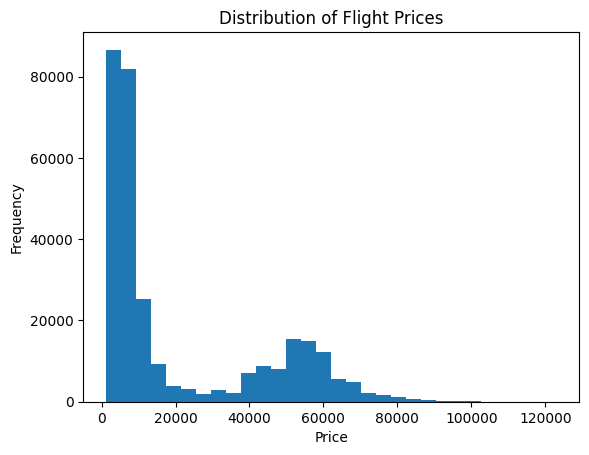

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(df["price"], bins=30)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

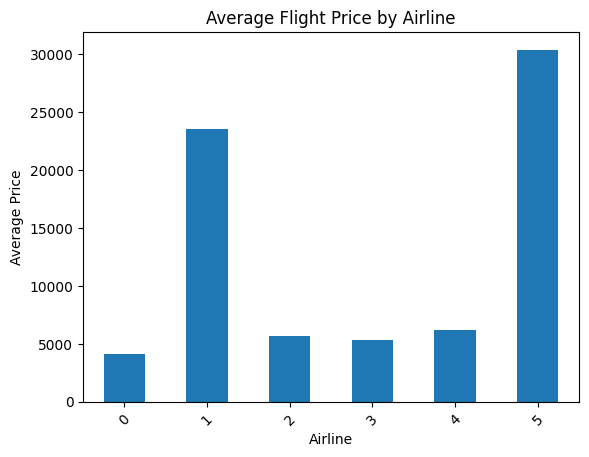

In [19]:
df.groupby("airline")["price"].mean().plot(kind="bar")
plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

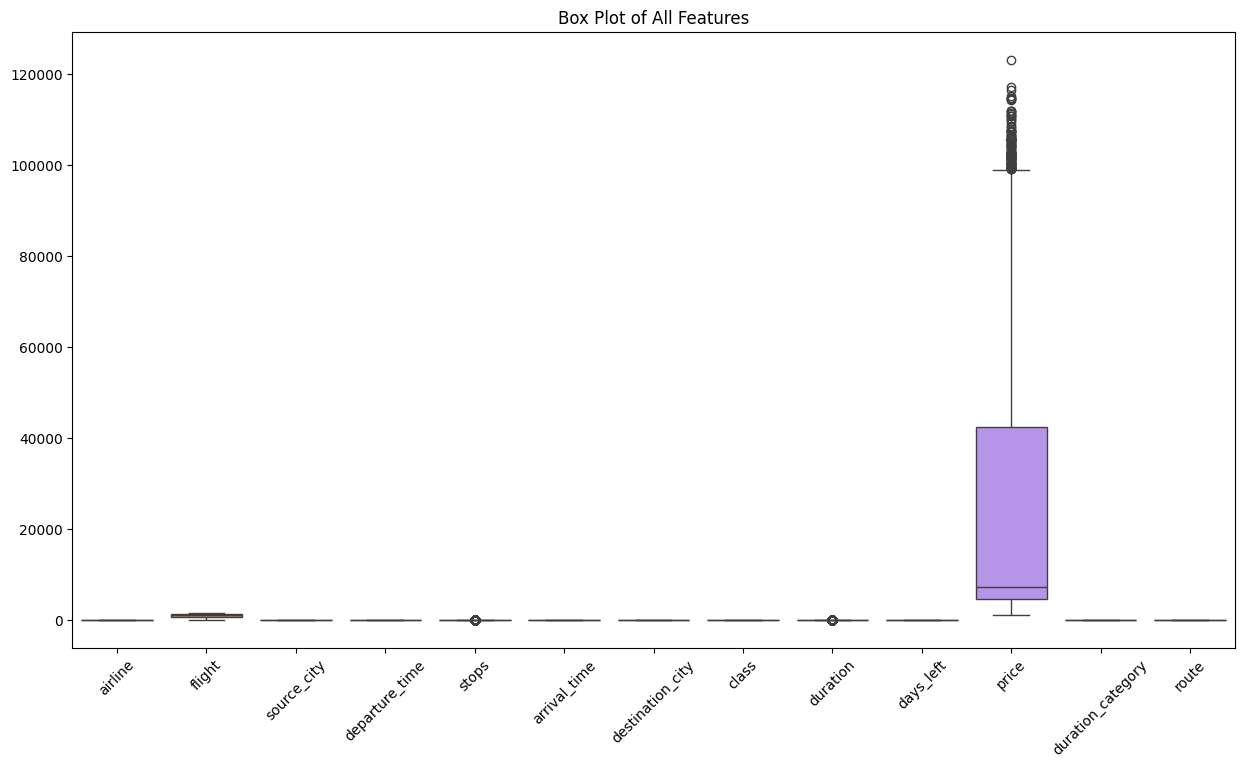

In [20]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of All Features")
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error


In [22]:
x=df.drop("price",axis=1)
y=df["price"]

In [23]:
x.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'duration_category', 'route'],
      dtype='object')

In [24]:
print(y.name)

price


In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [26]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240122, 12)
(60031, 12)
(240122,)
(60031,)


In [27]:
y_pred=rf.predict(x_test)

In [28]:
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",root_mean_squared_error(y_test,y_pred))
print("mae:",mean_absolute_error(y_test,y_pred))
print("r2 score:",r2_score(y_test,y_pred))

mse: 5423891.994937795
rmse: 2328.925072847513
mae: 863.663704327169
r2 score: 0.9894780242249919


In [29]:
print("train score:",rf.score(x_train,y_train))
print("test score:",rf.score(x_test,y_test))

train score: 0.9985091676436924
test score: 0.9894780242249919


In [30]:
sample_data = pd.DataFrame({
    "airline": [2],
    "flight": [150],
    "source_city": [1],
    "departure_time": [3],
    "stops": [0],
    "arrival_time": [2],
    "destination_city": [4],
    "class": [0],
    "duration": [2.5],
    "days_left": [15],
    "duration_category": [1],
    "route": [10]
})

prediction = rf.predict(sample_data)
print("Predicted Price:", prediction[0])

Predicted Price: 26804.48


In [31]:
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=100,max_depth=8,max_leaves=3,random_state=42)
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=3, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [32]:
y_pred=xgb.predict(x_test)

In [33]:
print("mse:",mean_squared_error(y_test,y_pred))
print("rmse:",root_mean_squared_error(y_test,y_pred))
print("mae:",mean_absolute_error(y_test,y_pred))
print("r2 score:",r2_score(y_test,y_pred))

mse: 25539238.0
rmse: 5053.63623046875
mae: 3103.714111328125
r2 score: 0.9504556655883789


In [34]:
print("train score:",xgb.score(x_train,y_train))
print("test score:",xgb.score(x_test,y_test))

train score: 0.951219916343689
test score: 0.9504556655883789


In [35]:
import pickle
with open("rf.pkl", "wb") as f:
  pickle.dump(rf, f)
from google.colab import files
files.download("rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>